In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('car_sales.csv')

In [3]:
df.head()

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,320
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,Sprinter 212
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,S 500
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,Q7
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,Rav 4


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4345 entries, 0 to 4344
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         4345 non-null   str    
 1   Price         4173 non-null   float64
 2   Body          4345 non-null   str    
 3   Mileage       4345 non-null   int64  
 4   EngineV       4195 non-null   float64
 5   Engine Type   4345 non-null   str    
 6   Registration  4345 non-null   str    
 7   Year          4345 non-null   int64  
 8   Model         4345 non-null   str    
dtypes: float64(2), int64(2), str(5)
memory usage: 305.6 KB


In [5]:
df.shape

(4345, 9)

In [6]:
df.describe()

,Price,Mileage,EngineV,Year
count,4173.000000,4345.000000,4195.000000,4345.000000
mean,19418.746935,161.237284,2.790734,2006.550058
std,25584.242620,105.705797,5.066437,6.719097
min,600.000000,0.000000,0.600000,1969.000000
25%,6999.000000,86.000000,1.800000,2003.000000
50%,11500.000000,155.000000,2.200000,2008.000000
75%,21700.000000,230.000000,3.000000,2012.000000
max,300000.000000,980.000000,99.990000,2016.000000


In [7]:
df.isnull().sum()

Brand             0
Price           172
Body              0
Mileage           0
EngineV         150
Engine Type       0
Registration      0
Year              0
Model             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(73)

In [9]:
df[df.duplicated()]

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
348,Mercedes-Benz,199999.0,crossover,0,5.50,Petrol,yes,2016,GLS 63
371,Mercedes-Benz,NaN,van,0,2.20,Diesel,yes,2016,V 250
390,Mercedes-Benz,NaN,crossover,0,4.60,Petrol,yes,2016,GLS 500
602,Mercedes-Benz,199999.0,crossover,0,5.50,Petrol,yes,2016,GLS 63
685,Mercedes-Benz,NaN,van,0,2.20,Diesel,yes,2016,V 250
...,...,...,...,...,...,...,...,...,...
4167,Mercedes-Benz,43500.0,other,51,3.00,Diesel,yes,2014,E-Class
4204,Mercedes-Benz,20500.0,sedan,173,1.80,Gas,yes,2011,E-Class
4231,Mercedes-Benz,NaN,crossover,27,3.00,Diesel,yes,2015,G 350
4274,Mercedes-Benz,109999.0,crossover,0,2.98,Diesel,yes,2016,GLS 350


In [10]:
df_clean = df.drop_duplicates()

In [11]:
pip install category_encoders --quiet

Note: you may need to restart the kernel to use updated packages.


In [12]:
pip install xgboost --quiet

Note: you may need to restart the kernel to use updated packages.


In [13]:
df_clean['Price'].isna().sum()

np.int64(149)

In [14]:
df_clean = df_clean.dropna(subset=['Price'])

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from category_encoders import TargetEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import root_mean_squared_error, r2_score

X = df_clean.drop(columns='Price')
y = df_clean['Price']

target_cols = ['Brand', 'Model']
ohe_cols = ['Body', 'Engine Type']
binary_cols = ['Registration']

num_cols = ['Mileage', 'EngineV', 'Year']

target_cols_transformer = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('trg', TargetEncoder(handle_unknown='value', handle_missing='value')),
])

ohe_cols_transformer = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')), 
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

binary_cols_transformer = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')), 
    ('bin', FunctionTransformer(lambda x: (x == 'Yes').astype(int), feature_names_out='one-to-one')),
])

num_cols_transformer = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('scl', StandardScaler()),
])

preprocessor = ColumnTransformer([
    ('target_cols', target_cols_transformer, target_cols),
    ('ohe_cols', ohe_cols_transformer, ohe_cols),
    ('binary_cols', binary_cols_transformer, binary_cols),
    ('num_cols', num_cols_transformer, num_cols),
])

models = {
    'linear': LinearRegression(),
    'ridge': Ridge(),
    'xgb': XGBRegressor(
    n_estimators=500,
    random_state=42),
    'rf': RandomForestRegressor(
    n_estimators=500,
    random_state=42),
}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

for name, regressor in models.items():
    model = Pipeline([
        ('preprocessing', preprocessor),
        ('regressor', regressor),
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{name} - RMSE: {rmse:.2f}, R2: {r2:.2f}")



linear - RMSE: 14542.64, R2: 0.55
ridge - RMSE: 14542.43, R2: 0.55
xgb - RMSE: 9143.34, R2: 0.82
rf - RMSE: 8268.05, R2: 0.86


In [16]:
xgb_model = Pipeline([
    ('preprocessing', preprocessor),
    ('regressor', XGBRegressor(random_state=42))
])

param_dist = {
    'regressor__n_estimators': [300, 500, 800, 1000],
    'regressor__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'regressor__max_depth': [3, 4, 5, 6, 7],
    'regressor__subsample': [0.7, 0.8, 0.9, 1.0],
    'regressor__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
}

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=25,
    scoring='r2',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

best_xgb = random_search.best_estimator_

y_pred = best_xgb.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print(random_search.best_params_)


Fitting 3 folds for each of 25 candidates, totalling 75 fits
R2: 0.8502907379721899
RMSE: 8431.936345832426
{'regressor__subsample': 1.0, 'regressor__n_estimators': 500, 'regressor__max_depth': 7, 'regressor__learning_rate': 0.05, 'regressor__colsample_bytree': 0.7}


In [24]:
rf_model = Pipeline([
    ('preprocessing', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

param_dist_rf = {
    'regressor__n_estimators': [300, 500, 800, 1000],
    'regressor__max_depth': [None, 10, 20, 30, 40],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4],
    'regressor__max_features': ['sqrt', 'log2', 0.7, 0.8, 1.0]
}

rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist_rf,
    n_iter=25,
    scoring='r2',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_

y_pred = best_rf.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print(rf_search.best_params_)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
R2: 0.8791840364256504
RMSE: 7574.694915338749
{'regressor__n_estimators': 800, 'regressor__min_samples_split': 2, 'regressor__min_samples_leaf': 1, 'regressor__max_features': 'sqrt', 'regressor__max_depth': 30}


In [ ]:
feature_names = best_rf.named_steps['preprocessing'].get_feature_names_out()
importances = best_rf.named_steps['regressor'].feature_importances_

fi = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

fi.head(15)

,feature,importance
1,target_cols__1,0.290980
15,num_cols__Year,0.207734
13,num_cols__Mileage,0.206181
14,num_cols__EngineV,0.149976
0,target_cols__0,0.065250
2,ohe_cols__Body_crossover,0.027889
11,ohe_cols__Engine Type_Petrol,0.011132
8,ohe_cols__Engine Type_Diesel,0.009488
4,ohe_cols__Body_other,0.009468
5,ohe_cols__Body_sedan,0.009053


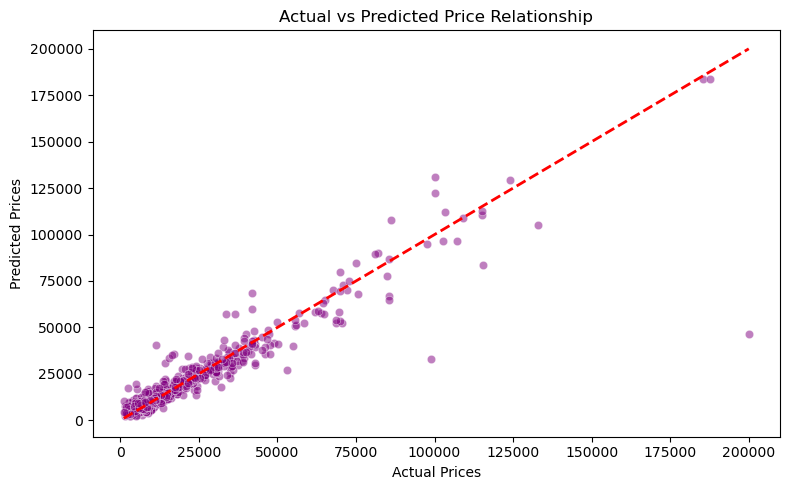

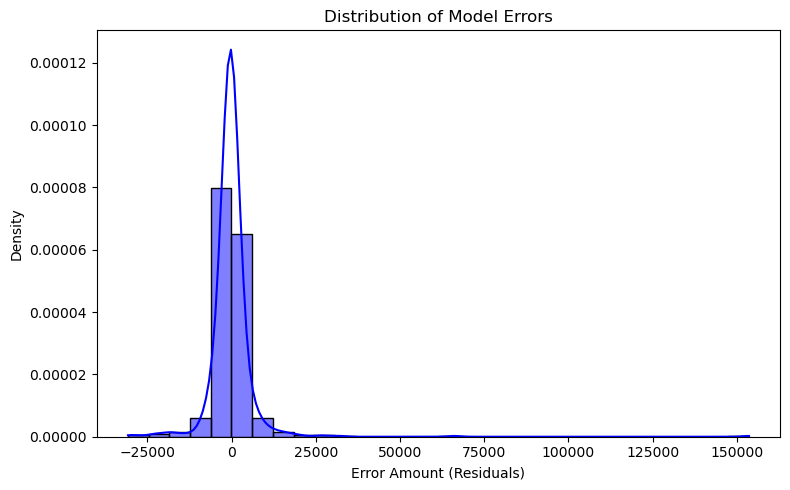

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color="purple")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "--",
    lw=2,
    color="red",
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Price Relationship")
plt.tight_layout()
plt.show()

residuals = y_test - y_pred
plt.figure(figsize=(8, 5))

sns.histplot(residuals, kde=True, color="blue", bins=30, stat="density")

plt.xlabel("Error Amount (Residuals)")
plt.title("Distribution of Model Errors")
plt.tight_layout()
plt.show()

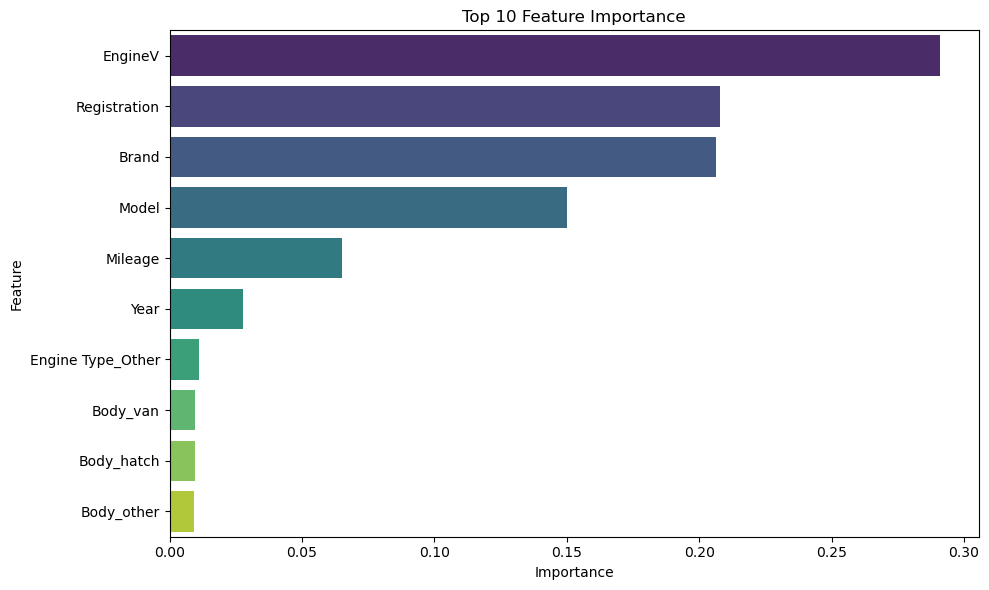

In [34]:
model_pipeline = best_rf
preprocessor = model_pipeline.named_steps['preprocessing']

ohe = preprocessor.named_transformers_['ohe_cols'].named_steps['ohe'].get_feature_names_out(ohe_cols)

features = num_cols + list(ohe) + target_cols + binary_cols

importances = model_pipeline.named_steps['regressor'].feature_importances_

feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(10)

# plot
plt.figure(figsize=(10, 6))
# Xəbərdarlığı silmək üçün hue və legend parametrləri əlavə edildi
sns.barplot(data=feat_imp, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Top 10 Feature Importance')
plt.tight_layout()
plt.show()
